In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import ImageGenerator, ImageDiscriminator
from synthetic_generation.gan.process import GANProcess



/home/ec2-user/miniconda3/envs/GAN/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load MNIST, normalize to [-1, 1] to match tanh output
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 66.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 110MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.52MB/s]


In [3]:
class MNISTConditionalDataset(Dataset):
    def __init__(self, mnist_dataset, num_classes=10):
        self.dataset = mnist_dataset
        self.num_classes = num_classes
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        one_hot = torch.zeros(self.num_classes)
        one_hot[label] = 1.0
        return image, one_hot

In [18]:
conditional_dataset = MNISTConditionalDataset(train_dataset)
dataloader = DataLoader(conditional_dataset, batch_size=512, shuffle=True)

In [ ]:
G = ImageGenerator(noise_dim = 100, output_dim = (1,28,28), conv_in_channels=256, num_conv_layers=2, conditional_dim = 10)
D = ImageDiscriminator(feature_dim = (1, 28, 28), conv_out_channels=64, num_conv_layers=2, conditional_dim=10)
process = GANProcess(G=G, D=D)
history = process.train(
    X=dataloader,
)

GAN training: 100%|██████████| 200/200 [1:12:40<00:00, 21.80s/it, D=0.3655, G=2.7455]


([(1, np.float64(1.868459398463621)),
  (2, np.float64(1.5987272272675723)),
  (3, np.float64(1.717829695697558)),
  (4, np.float64(2.0046411964852933)),
  (5, np.float64(2.2589795326782487)),
  (6, np.float64(2.41774235640542)),
  (7, np.float64(2.545470566062604)),
  (8, np.float64(2.6355009877075584)),
  (9, np.float64(2.6775773561606973)),
  (10, np.float64(2.7148715813281172)),
  (11, np.float64(2.7283802032470703)),
  (12, np.float64(2.7291507114798335)),
  (13, np.float64(2.6943506729804865)),
  (14, np.float64(2.6806809710244)),
  (15, np.float64(2.668349815627276)),
  (16, np.float64(2.6500741889921287)),
  (17, np.float64(2.6273658912060625)),
  (18, np.float64(2.6052761572902488)),
  (19, np.float64(2.575706189466735)),
  (20, np.float64(2.5413432449607525)),
  (21, np.float64(2.5287020166041487)),
  (22, np.float64(2.498939475770724)),
  (23, np.float64(2.5175774653079146)),
  (24, np.float64(2.4298177603947915)),
  (25, np.float64(2.436987299535234)),
  (26, np.float64(2.4

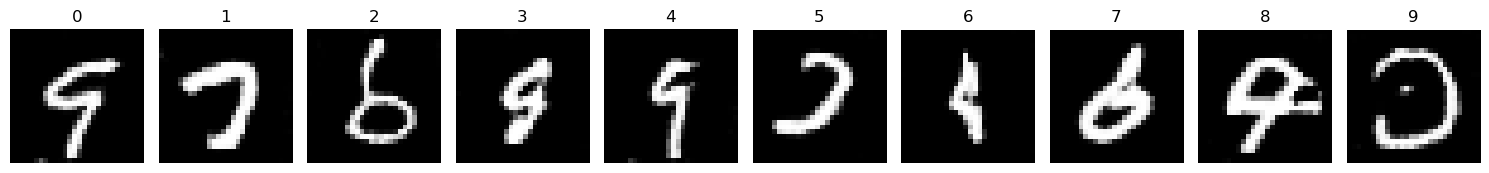

In [ ]:



# generate one sample per digit class
samples = []
for digit in range(10):
    c = torch.zeros(1, 10)
    c[0, digit] = 1.0
    sample = process.generate_samples(1, c=c)
    samples.append(sample)

# plot in a row
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, (ax, sample) in enumerate(zip(axes, samples)):
    ax.imshow(sample.squeeze(), cmap='gray')
    ax.set_title(str(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

In [29]:
G = ImageGenerator(noise_dim = 100, output_dim = (1,28,28), conv_in_channels=256, num_conv_layers=2, conditional_dim = 10)
D = ImageDiscriminator(feature_dim = (1, 28, 28), conv_out_channels=64, num_conv_layers=2, conditional_dim=10)
process = GANProcess(G=G, D=D)
history = process.train(
    X=dataloader,
    lambda_fm_1 = 1e-4,
    lambda_fm_2 = 1e-4,
)

GAN training: 100%|██████████| 200/200 [1:25:02<00:00, 25.51s/it, D=0.3403, G=2.8232]


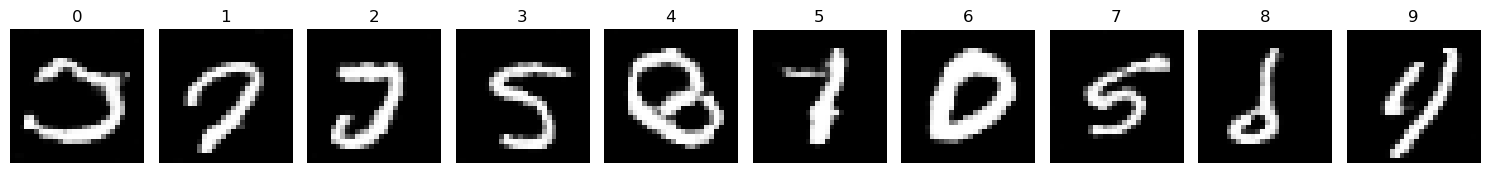

In [30]:
# generate one sample per digit class
samples = []
for digit in range(10):
    c = torch.zeros(1, 10)
    c[0, digit] = 1.0
    sample = process.generate_samples(1, c=c)
    samples.append(sample)

# plot in a row
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, (ax, sample) in enumerate(zip(axes, samples)):
    ax.imshow(sample.squeeze(), cmap='gray')
    ax.set_title(str(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

In [31]:
G = ImageGenerator(noise_dim = 100, output_dim = (1,28,28), conv_in_channels=256, num_conv_layers=2, conditional_dim = 10)
D = ImageDiscriminator(feature_dim = (1, 28, 28), conv_out_channels=64, num_conv_layers=2, conditional_dim=10)
process = GANProcess(G=G, D=D)
history_2 = process.train(
    X=dataloader,
    lambda_fm_1 = 1e-3,
    lambda_fm_2 = 1e-4,
)

GAN training: 100%|██████████| 200/200 [1:25:06<00:00, 25.53s/it, D=0.3643, G=2.7567]


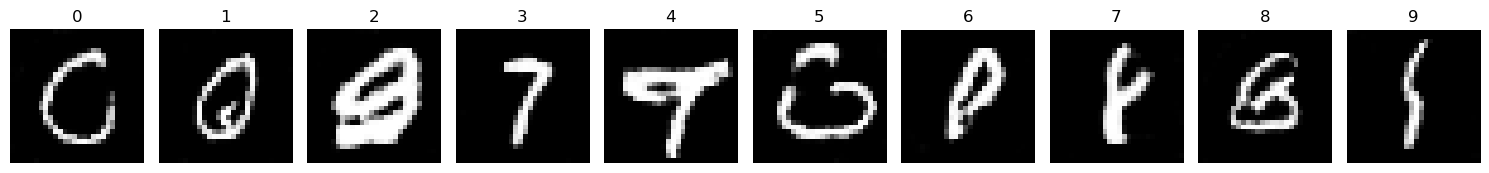

In [32]:
# generate one sample per digit class
samples = []
for digit in range(10):
    c = torch.zeros(1, 10)
    c[0, digit] = 1.0
    sample = process.generate_samples(1, c=c)
    samples.append(sample)

# plot in a row
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, (ax, sample) in enumerate(zip(axes, samples)):
    ax.imshow(sample.squeeze(), cmap='gray')
    ax.set_title(str(i))
    ax.axis('off')
plt.tight_layout()
plt.show()